# Notebook 05 — Centroid B: Relative-Position Per-Turn Centroids

For each conversation, extract turns at three relative positions (early / middle / late),
build separate centroid sets per position, and evaluate whether harmful–benign separation
improves across the trajectory.

**Data:** Mode B — `results/representations/mode_b/` (attempts 1-4 train, attempt 5 test)

## Section 1: Setup & Load

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEB_ROOT = repo_root / "results" / "representations" / "mode_b"
FIG_DIR    = repo_root / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FRAMEWORKS  = ["crescendo", "actorattack", "xteaming"]
FW_PALETTE  = {"crescendo": "#4C72B0", "actorattack": "#DD8452", "xteaming": "#55A868"}
N_LAYERS    = 32
HIDDEN_DIM  = 4096
STAGES      = ["early", "middle", "late"]

print("repo_root:", repo_root)

repo_root: /Users/lisahusieva/Desktop/multi-turn-rep-eng


In [2]:
# Load Mode B arrays (memory-mapped) and metadata
data = {}  # key -> {"meta": DataFrame, "h_inst": mmap}

for fw in FRAMEWORKS:
    for gt in ("harmful", "benign"):
        key    = f"{fw}_{gt}"
        folder = MODEB_ROOT / key
        if not folder.exists():
            print(f"  MISSING: {key}")
            continue
        meta   = pd.read_parquet(folder / "metadata.parquet")
        h_inst = np.load(str(folder / "h_inst.npy"), mmap_mode="r")
        data[key] = {"meta": meta, "h_inst": h_inst}
        print(f"  {key}: {meta.shape[0]} rows, h_inst {h_inst.shape}")

# Build combined per-framework DataFrame with positional index into the mmap
fw_dfs = {}
for fw in FRAMEWORKS:
    parts = []
    for gt in ("harmful", "benign"):
        key = f"{fw}_{gt}"
        if key not in data:
            continue
        m = data[key]["meta"].copy()
        m["_key"] = key
        m["_idx"] = np.arange(len(m))
        parts.append(m)
    fw_dfs[fw] = pd.concat(parts, ignore_index=True)

print("\nCombined sizes:", {fw: len(df) for fw, df in fw_dfs.items()})

  crescendo_harmful: 2902 rows, h_inst (2902, 32, 4096)
  crescendo_benign: 1961 rows, h_inst (1961, 32, 4096)
  actorattack_harmful: 2994 rows, h_inst (2994, 32, 4096)
  actorattack_benign: 3000 rows, h_inst (3000, 32, 4096)
  xteaming_harmful: 1589 rows, h_inst (1589, 32, 4096)
  xteaming_benign: 1744 rows, h_inst (1744, 32, 4096)

Combined sizes: {'crescendo': 4863, 'actorattack': 5994, 'xteaming': 3333}


## Section 2: Relative-Position Turn Selection

For each conversation (`conversation_id`), select:
- **early** — turn closest to `round(n_accepted_turns / 3)`
- **middle** — turn closest to `round(2 * n_accepted_turns / 3)`
- **late** — turn == `n_accepted_turns` (final turn)

In [3]:
def select_stage_rows(df):
    """
    Given a combined DataFrame with turn_k and n_accepted_turns,
    return a dict of stage -> DataFrame (one row per conversation).
    """
    records = {s: [] for s in STAGES}

    for conv_id, grp in df.groupby("conversation_id"):
        n = grp["n_accepted_turns"].iloc[0]
        targets = {
            "early":  round(n / 3),
            "middle": round(2 * n / 3),
            "late":   n,
        }
        for stage, target_k in targets.items():
            # Pick the row whose turn_k is closest to target_k
            best_row = grp.iloc[(grp["turn_k"] - target_k).abs().argsort().iloc[:1]]
            records[stage].append(best_row)

    return {s: pd.concat(v, ignore_index=True) for s, v in records.items()}


# Apply to train (attempt < 5) and test (attempt == 5) splits
fw_stage_train = {}   # fw -> stage -> DataFrame
fw_stage_test  = {}   # fw -> stage -> DataFrame

for fw in FRAMEWORKS:
    df    = fw_dfs[fw]
    train = df[df["attempt"] < 5].reset_index(drop=True)
    test  = df[df["attempt"] == 5].reset_index(drop=True)
    fw_stage_train[fw] = select_stage_rows(train)
    fw_stage_test[fw]  = select_stage_rows(test)
    for s in STAGES:
        print(f"  {fw} {s}: train={len(fw_stage_train[fw][s])} test={len(fw_stage_test[fw][s])}")

  crescendo early: train=780 test=194
  crescendo middle: train=780 test=194
  crescendo late: train=780 test=194
  actorattack early: train=800 test=199
  actorattack middle: train=800 test=199
  actorattack late: train=800 test=199
  xteaming early: train=786 test=198
  xteaming middle: train=786 test=198
  xteaming late: train=786 test=198


## Section 3: Centroid Construction

For each (framework, stage) build:
- `v_harmful` (32, 4096): within-pair subtraction direction
- `mu_harmful` (32, 4096): mean over accepted harmful train rows
- `mu_harmless` (32, 4096): mean over accepted benign train rows

In [4]:
def get_h(rows_df):
    """Fetch h_inst for rows; returns float32 (N, 32, 4096)."""
    parts = []
    for key, grp in rows_df.groupby("_key"):
        arr   = data[key]["h_inst"]
        chunk = arr[grp["_idx"].values].astype(np.float32)
        parts.append(chunk)
    return np.concatenate(parts, axis=0) if parts else np.empty((0, N_LAYERS, HIDDEN_DIM), dtype=np.float32)


def build_centroids(stage_df):
    """
    stage_df: one row per conversation for this stage (train split).
    Returns dict with v_harmful, mu_harmful, mu_harmless (all (32,4096) float32).
    """
    # Verdict-based labels
    harm = stage_df[stage_df["goal_type"] == "harmful"]
    ben  = stage_df[stage_df["goal_type"] == "benign"]

    accepted_harm = harm[harm["verdict"] == "jailbroken"]
    refused_harm  = harm[harm["verdict"].isin(["refusal", "near_miss"])]

    # For benign: use final_turn_outcome to identify accepted conversations
    accepted_ben  = ben[ben["final_turn_outcome"] == "accepted"] if "final_turn_outcome" in ben.columns else ben

    mu_harmful  = get_h(harm).mean(axis=0)         if len(harm) > 0 else np.zeros((N_LAYERS, HIDDEN_DIM), np.float32)
    mu_harmless = get_h(accepted_ben).mean(axis=0) if len(accepted_ben) > 0 else np.zeros((N_LAYERS, HIDDEN_DIM), np.float32)

    # v_harmful: mean of within-pair difference vectors + PCA variance diagnostic
    from sklearn.decomposition import PCA
    diff_vecs = []
    for pair_id, grp in stage_df.groupby("pair_id"):
        h_grp = grp[grp["goal_type"] == "harmful"]
        b_grp = grp[grp["goal_type"] == "benign"]
        if len(h_grp) == 0 or len(b_grp) == 0:
            continue
        h_vec = get_h(h_grp).mean(axis=0)   # (32, 4096)
        b_vec = get_h(b_grp).mean(axis=0)
        diff_vecs.append(h_vec - b_vec)
    n_pairs = len(diff_vecs)
    v = np.zeros((N_LAYERS, HIDDEN_DIM), dtype=np.float32)
    if n_pairs > 0:
        diff_arr = np.stack(diff_vecs, axis=0)   # (n_pairs, 32, 4096)
        v = diff_arr.mean(axis=0).astype(np.float32)
        _pca = PCA(n_components=1)
        var_exp = np.array([
            _pca.fit(diff_arr[:, l, :]).explained_variance_ratio_[0]
            for l in range(N_LAYERS)
        ])
        print(f"    v_harmful: {n_pairs} pairs  "
              f"PC1_var_exp mean={var_exp.mean():.3f}  "
              f"max={var_exp.max():.3f} (layer {var_exp.argmax()+1})")

    return {"v_harmful": v, "mu_harmful": mu_harmful, "mu_harmless": mu_harmless}


# Build centroids for each (fw, stage)
stage_centroids = {}  # (fw, stage) -> centroid dict

for fw in FRAMEWORKS:
    for stage in STAGES:
        key = (fw, stage)
        stage_centroids[key] = build_centroids(fw_stage_train[fw][stage])
        print(f"  Built centroid: {fw} {stage}")

  Built centroid: crescendo early
  Built centroid: crescendo middle
  Built centroid: crescendo late
  Built centroid: actorattack early
  Built centroid: actorattack middle
  Built centroid: actorattack late
  Built centroid: xteaming early
  Built centroid: xteaming middle
  Built centroid: xteaming late


## Section 4: Evaluation

Score function: `Δ = mean_over_layers(cos_sim(h, mu_harmful) - cos_sim(h, mu_harmless))`

Threshold at 0. Evaluate:
1. **Within-stage**: early centroid vs early test turns, etc.
2. **Cross-stage**: e.g., early centroid vs late test turns.

In [5]:
def delta_score_batch(h_arr, mu_harmful, mu_harmless):
    """h_arr: (N,32,4096) float32. Returns (N,) scores."""
    h  = torch.tensor(h_arr,       dtype=torch.float32)
    mh = torch.tensor(mu_harmful,  dtype=torch.float32)
    mb = torch.tensor(mu_harmless, dtype=torch.float32)
    h_n  = F.normalize(h,  dim=2)           # (N,32,4096)
    mh_n = F.normalize(mh, dim=1)           # (32,4096)
    mb_n = F.normalize(mb, dim=1)
    sim_h = (h_n * mh_n.unsqueeze(0)).sum(dim=2)   # (N,32)
    sim_b = (h_n * mb_n.unsqueeze(0)).sum(dim=2)
    return (sim_h - sim_b).mean(dim=1).numpy()      # (N,)


def eval_cell(test_stage_df, centroid):
    """Return dict with harm_acc, ben_acc, overall_acc, n_harm, n_ben."""
    harm = test_stage_df[test_stage_df["goal_type"] == "harmful"]
    ben  = test_stage_df[test_stage_df["goal_type"] == "benign"]

    mu_h = centroid["mu_harmful"]
    mu_b = centroid["mu_harmless"]

    results = {}
    if len(harm) > 0:
        scores = delta_score_batch(get_h(harm), mu_h, mu_b)
        results["harm_acc"] = (scores > 0).mean()
        results["n_harm"]   = len(harm)
    else:
        results["harm_acc"] = np.nan; results["n_harm"] = 0
    if len(ben) > 0:
        scores = delta_score_batch(get_h(ben), mu_h, mu_b)
        results["ben_acc"] = (scores <= 0).mean()
        results["n_ben"]   = len(ben)
    else:
        results["ben_acc"] = np.nan; results["n_ben"] = 0

    n_total = results["n_harm"] + results["n_ben"]
    if n_total > 0:
        results["overall_acc"] = (
            results["harm_acc"] * results["n_harm"] +
            results["ben_acc"]  * results["n_ben"]
        ) / n_total
    else:
        results["overall_acc"] = np.nan
    return results


# Full cross-stage eval: centroid stage × test stage × framework
eval_records = []

for fw in FRAMEWORKS:
    for cent_stage in STAGES:
        centroid = stage_centroids[(fw, cent_stage)]
        for test_stage in STAGES:
            test_df = fw_stage_test[fw][test_stage]
            r = eval_cell(test_df, centroid)
            eval_records.append({
                "framework":   fw,
                "cent_stage":  cent_stage,
                "test_stage":  test_stage,
                **r
            })

eval_df = pd.DataFrame(eval_records)
print(eval_df.to_string(index=False))

  framework cent_stage test_stage  harm_acc  n_harm  ben_acc  n_ben  overall_acc
  crescendo      early      early  0.608247      97 0.752577     97     0.680412
  crescendo      early     middle  0.927835      97 0.257732     97     0.592784
  crescendo      early       late  0.989691      97 0.030928     97     0.510309
  crescendo     middle      early  0.298969      97 0.938144     97     0.618557
  crescendo     middle     middle  0.762887      97 0.711340     97     0.737113
  crescendo     middle       late  0.948454      97 0.505155     97     0.726804
  crescendo       late      early  0.175258      97 0.948454     97     0.561856
  crescendo       late     middle  0.505155      97 0.824742     97     0.664948
  crescendo       late       late  0.814433      97 0.835052     97     0.824742
actorattack      early      early  0.545455      99 0.710000    100     0.628141
actorattack      early     middle  0.616162      99 0.560000    100     0.587940
actorattack      early      

## Section 5: Per-Stage Eval Matrices

/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: Future

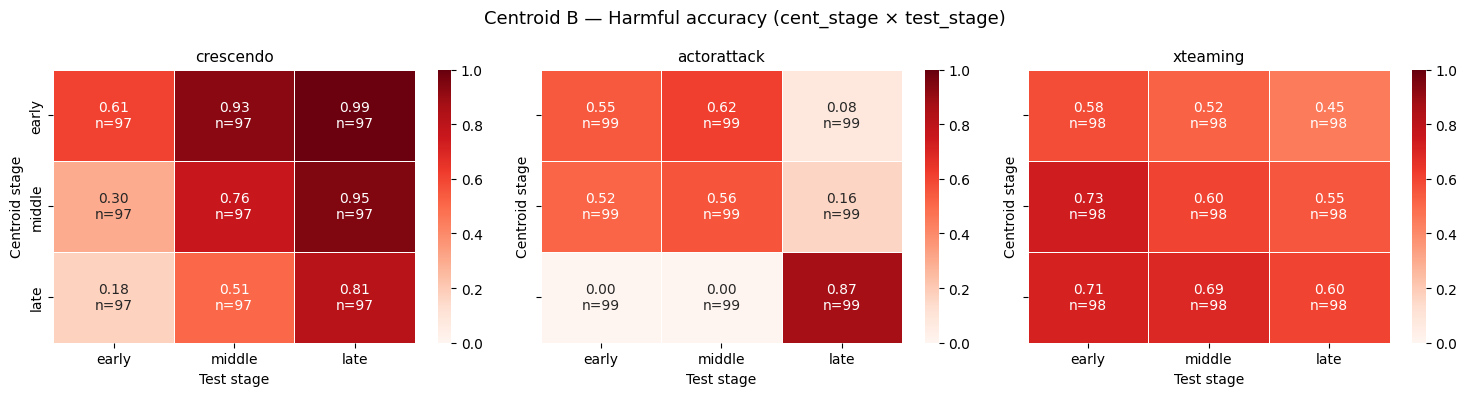

Saved /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/05_centroid_B_harm_acc.png


/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: Future

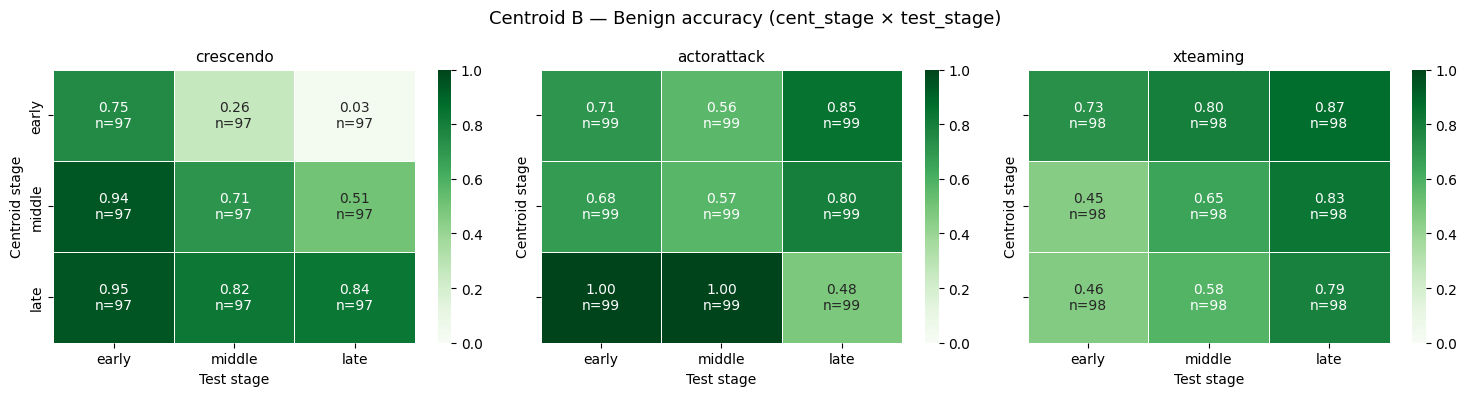

Saved /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/05_centroid_B_ben_acc.png


/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_79555/345397527.py:28: Future

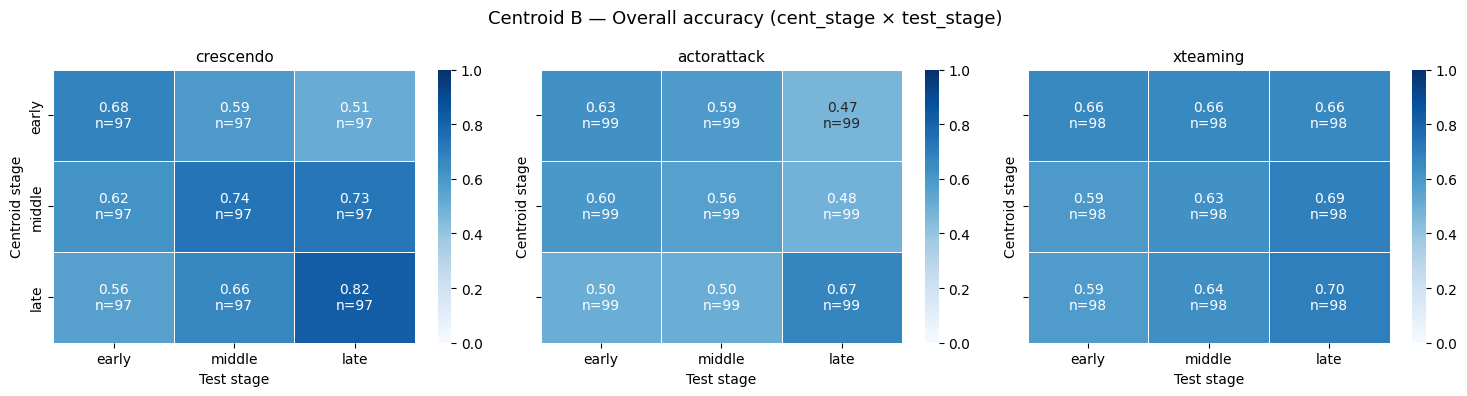

Saved /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/05_centroid_B_overall_acc.png


In [6]:
def make_heatmap(ax, matrix, annot, title, vmin=0, vmax=1, cmap="Blues"):
    sns.heatmap(
        matrix, annot=annot, fmt="", ax=ax,
        vmin=vmin, vmax=vmax, cmap=cmap,
        linewidths=0.5, cbar=True
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Test stage"); ax.set_ylabel("Centroid stage")


# One figure per framework, showing within-stage diagonal + cross-stage cells
for metric, label, cmap in [
    ("harm_acc",    "Harmful accuracy",  "Reds"),
    ("ben_acc",     "Benign accuracy",   "Greens"),
    ("overall_acc", "Overall accuracy",  "Blues"),
]:
    fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(5 * len(FRAMEWORKS), 4), sharey=True)
    fig.suptitle(f"Centroid B — {label} (cent_stage × test_stage)", fontsize=13)

    for ax, fw in zip(axes, FRAMEWORKS):
        sub = eval_df[eval_df["framework"] == fw]
        mat    = sub.pivot(index="cent_stage", columns="test_stage", values=metric)\
                    .reindex(index=STAGES, columns=STAGES)
        n_harm = sub.pivot(index="cent_stage", columns="test_stage", values="n_harm")\
                    .reindex(index=STAGES, columns=STAGES)
        n_ben  = sub.pivot(index="cent_stage", columns="test_stage", values="n_ben")\
                    .reindex(index=STAGES, columns=STAGES)
        annot  = mat.applymap(lambda x: f"{x:.2f}") + "\n" + \
                 n_harm.applymap(lambda x: f"n={int(x) if not np.isnan(x) else '?'}")
        make_heatmap(ax, mat.astype(float), annot.values, fw, cmap=cmap)

    plt.tight_layout()
    fname = FIG_DIR / f"05_centroid_B_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

## Section 6: Accuracy vs Stage (Within-Stage)

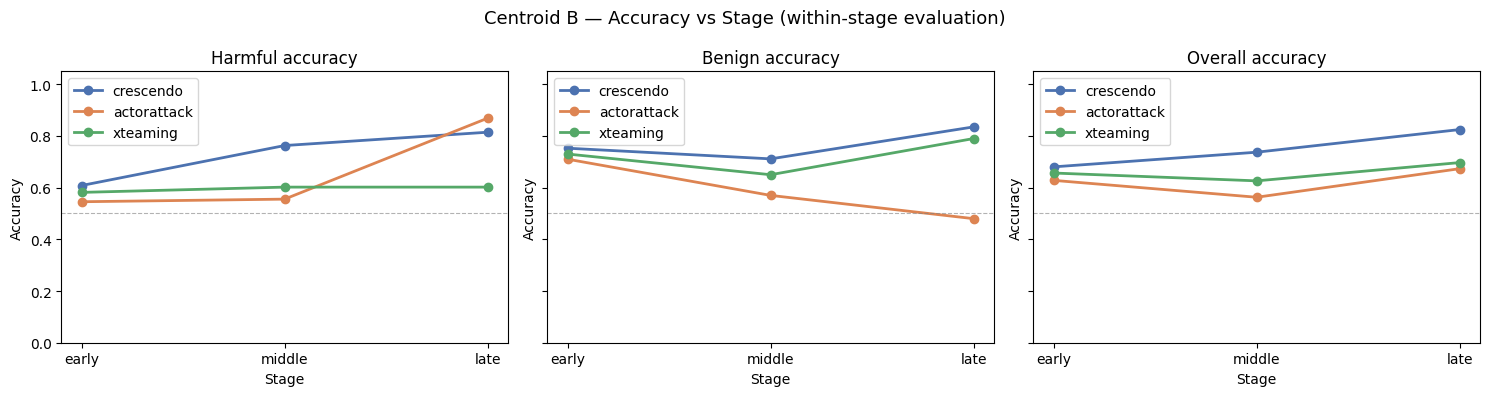

Saved /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/05_centroid_B_stage_lineplot.png


In [7]:
# Within-stage diagonal: cent_stage == test_stage
within = eval_df[eval_df["cent_stage"] == eval_df["test_stage"]].copy()
stage_order = {s: i for i, s in enumerate(STAGES)}
within["stage_num"] = within["test_stage"].map(stage_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Centroid B — Accuracy vs Stage (within-stage evaluation)", fontsize=13)

for ax, (metric, label) in zip(axes, [
    ("harm_acc",    "Harmful accuracy"),
    ("ben_acc",     "Benign accuracy"),
    ("overall_acc", "Overall accuracy"),
]):
    for fw in FRAMEWORKS:
        sub = within[within["framework"] == fw].sort_values("stage_num")
        ax.plot(sub["test_stage"], sub[metric], marker="o",
                label=fw, color=FW_PALETTE[fw], linewidth=2)
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, alpha=0.6)
    ax.set_title(label); ax.set_xlabel("Stage"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05); ax.legend()

plt.tight_layout()
fname = FIG_DIR / "05_centroid_B_stage_lineplot.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname}")

## Section 7: Summary

In [8]:
print("=" * 65)
print("SUMMARY: Centroid B — relative-position per-turn centroids")
print("=" * 65)

print("\nWithin-stage overall accuracy:")
pivot = within.pivot(index="framework", columns="test_stage", values="overall_acc")\
              .reindex(columns=STAGES)
print(pivot.round(3).to_string())

print("\nKey question: does separation improve early -> middle -> late?")
for fw in FRAMEWORKS:
    row = pivot.loc[fw]
    trend = "improving" if row["late"] > row["early"] else "not improving"
    print(f"  {fw}: early={row['early']:.3f} mid={row['middle']:.3f} late={row['late']:.3f}  [{trend}]")

SUMMARY: Centroid B — relative-position per-turn centroids

Within-stage overall accuracy:
test_stage   early  middle   late
framework                        
actorattack  0.628   0.563  0.673
crescendo    0.680   0.737  0.825
xteaming     0.657   0.626  0.697

Key question: does separation improve early -> middle -> late?
  crescendo: early=0.680 mid=0.737 late=0.825  [improving]
  actorattack: early=0.628 mid=0.563 late=0.673  [improving]
  xteaming: early=0.657 mid=0.626 late=0.697  [improving]
